# BrushCue Example: Conic Gradient

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/conic_gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/conic-gradient

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


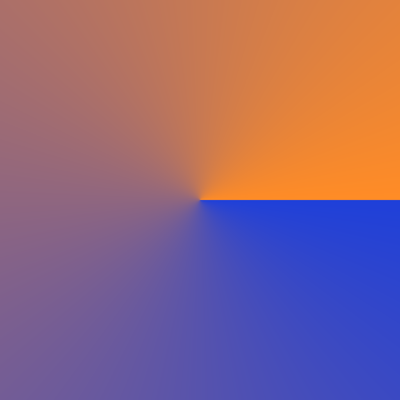

In [1]:
import io
from PIL import Image

import brushcue as bc

width = 1024
width_f = bc.Int.to_float(width)
height = 1024
height_f = bc.Int.to_float(height)
center_x = 0.5
center_y = 0.5
start_angle = 0.0
angle_rad = start_angle * 0.017453292
start_color = bc.ProfiledColor.from_srgb_hex("#1F40D9")
end_color = bc.ProfiledColor.from_srgb_hex("#FF8C26")
graph = bc.Composition.freeform_shader(
    "let size = vec2<f32>(width_f, height_f);\nlet c = vec2<f32>(center_x * size.x, center_y * size.y);\nlet d = canvas_position - c;\nlet a = atan2(d.y, d.x);\nlet t = fract((a - angle_rad) / 6.2831853);\nreturn mix(start_color, end_color, t);",
    "",
    bc.Bounds2f.from_x_y_width_height(0.0, 0.0, width_f, height_f),
    bc.ColorRepresentation.srgb(),
    bc.Dictionary.create()
    .add("width_f", width_f)
    .add("height_f", height_f)
    .add("center_x", center_x)
    .add("center_y", center_y)
    .add("angle_rad", angle_rad)
    .add("start_color", start_color)
    .add("end_color", end_color),
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
